# High-z Example 13: The z > 5 Subsample

**EPS Research — High-z Kinematic Corpus Z1**

9 of 31 Z1 galaxies lie at z > 5, approaching cosmic reionization.
3 of these are confirmed rotators, making them among the most
distant kinematically-resolved disk galaxies known.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369285  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

rows = []
with open('high_z_kinematic_corpus_Z1_flat.csv') as f:
    for r in csv.DictReader(f):
        rows.append(r)
print(f"Total galaxies: {len(rows)}")


Total galaxies: 31


In [2]:
import numpy as np
z5 = [r for r in rows if float(r['redshift']) > 5.0]
print(f"Galaxies at z > 5: {len(z5)}")
from collections import Counter
classes = Counter(r['class_jones2021'] for r in z5)
print(f"Classes: {dict(classes)}")
print(f"\n{'Galaxy':<20} {'z':>7} {'Class':>6} {'log M*':>8} {'SFR':>8}")
print('-'*55)
for r in sorted(z5, key=lambda x: float(x['redshift']), reverse=True):
    print(f"{r['galaxy']:<20} {float(r['redshift']):>7.4f} "
          f"{r['class_jones2021']:>6} "
          f"{r.get('log_mstar_msun','?'):>8} "
          f"{r.get('sfr_msun_yr','?'):>8}")


Galaxies at z > 5: 9
Classes: {'UNC': 4, 'ROT': 3, 'DIS': 1, 'MER': 1}

Galaxy                     z  Class   log M*      SFR
-------------------------------------------------------
DC773957              5.6773    UNC      9.8     18.0
DC417567              5.6700    UNC     10.0     30.0
DC519281              5.5800    UNC      9.7     15.0
DC494057              5.5446    ROT     10.0     40.0
DC683613              5.5421    UNC      9.9     25.0
HZ9                   5.5413    ROT     10.3     80.0
DC552206              5.5016    ROT     10.4    120.0
DC848185              5.2930    DIS     10.3     90.0
DC873321              5.1544    MER     10.2     60.0


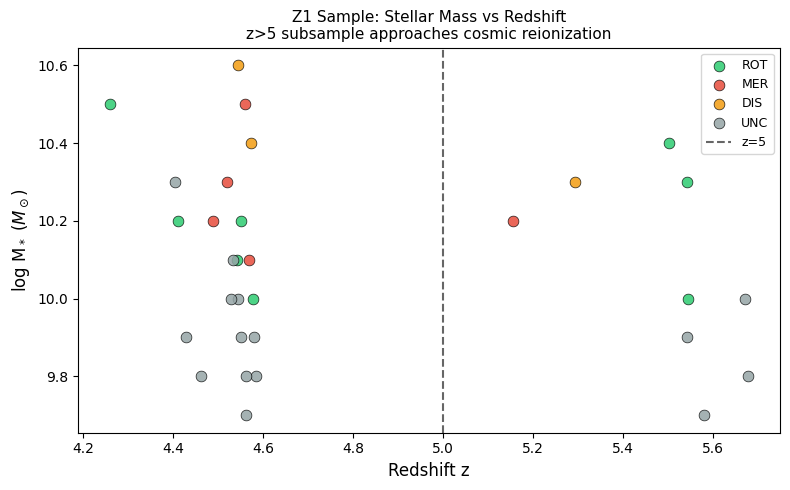

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
COLORS = {'ROT':'#2ecc71','MER':'#e74c3c','DIS':'#f39c12','UNC':'#95a5a6'}

for cls, color in COLORS.items():
    sub = [r for r in rows if r['class_jones2021']==cls]
    zs  = [float(r['redshift']) for r in sub]
    ms  = [float(r['log_mstar_msun']) for r in sub if r.get('log_mstar_msun')]
    zs  = [float(r['redshift']) for r in sub if r.get('log_mstar_msun')]
    if zs:
        ax.scatter(zs, ms, s=60, color=color, label=f'{cls}', alpha=0.85,
                   edgecolors='k', linewidths=0.5)

ax.axvline(5.0, color='black', ls='--', lw=1.5, alpha=0.6, label='z=5')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel(r'log M$_*$ ($M_\odot$)', fontsize=12)
ax.set_title('Z1 Sample: Stellar Mass vs Redshift\n'
             'z>5 subsample approaches cosmic reionization', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('hz13_z5_subsample.png', dpi=150, bbox_inches='tight')
plt.show()